#### __About the dataset__


#### __Dataset Description__

The dataset contains historical and projected life expectancy data for countries around the world, spanning the years 1800 to 2100. Each record represents the average life expectancy for a specific country in a given year, enabling the analysis of long-term health trends across different regions.

#### __The dataset includes key variables such as:__

- name – Country name.
- year – The observation year (1800–2100).
- life_expectancy – Average life expectancy at birth, measured in years.


Overall, the dataset provides valuable insights into how advances in healthcare, nutrition, sanitation, education, and socioeconomic development have contributed to increasing life expectancy worldwide over time.

[**Data Source**]("https://www.gapminder.org/data/")

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [2]:
df = pd.read_csv(".\data\life_expectancy.csv")

In [3]:
df.head()

,geo,name,1800,1801,1802,1803,1804,1805,1806,1807,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
0,afg,Afghanistan,28.21,28.20,28.19,28.18,28.17,28.16,28.15,28.14,...,79.09,79.19,79.29,79.50,79.61,79.71,79.81,80.02,80.12,80.23
1,ago,Angola,26.98,26.98,26.98,26.98,26.98,26.98,26.98,26.98,...,73.56,73.66,73.76,73.95,74.05,74.15,74.35,74.45,74.55,74.65
2,alb,Albania,35.40,35.40,35.40,35.40,35.40,35.40,35.40,35.40,...,89.10,89.20,89.30,89.40,89.50,89.60,89.70,89.80,89.90,90.00
3,and,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,91.89,92.09,92.19,92.29,92.39,92.49,92.59,92.69,92.79,92.89
4,are,UAE,30.70,30.70,30.70,30.70,30.70,30.70,30.70,30.70,...,87.64,87.73,87.83,87.93,88.02,88.12,88.22,88.31,88.41,88.51


#### **Understand the data**

In [4]:
print(df.shape)

(194, 303)


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Columns: 303 entries, geo to 2100
dtypes: float64(301), object(2)
memory usage: 459.4+ KB
None


In [6]:
print(df.isna().sum())

geo      0
name     0
1800    10
1801    10
1802    10
        ..
2096     1
2097     1
2098     1
2099     1
2100     1
Length: 303, dtype: int64


#### **Clean the Data**

**Remove duplicates**

In [7]:
df = df.drop_duplicates()

__Check missing values__

In [8]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

missing.head(20)

1949    10
1893    10
1895    10
1896    10
1897    10
1898    10
1899    10
1900    10
1901    10
1902    10
1903    10
1904    10
1905    10
1906    10
1907    10
1908    10
1909    10
1894    10
1892    10
1912    10
dtype: int64

__Convert from wide format to long format.__

In [9]:
life = df.melt(
    id_vars=["geo","name"],
    var_name="year",
    value_name="life_expectancy"
)

In [10]:
life.head()

,geo,name,year,life_expectancy
0,afg,Afghanistan,1800,28.21
1,ago,Angola,1800,26.98
2,alb,Albania,1800,35.40
3,and,Andorra,1800,NaN
4,are,UAE,1800,30.70


In [11]:
print(life.shape)

(58394, 4)


__Convert Year to numeric__

In [12]:
life["year"] = life["year"].astype(int)

__Convert Life Expectancy to numeric and drop the missing values__

In [13]:
life["life_expectancy"] = pd.to_numeric(life["life_expectancy"], errors="coerce")
life = life.dropna(subset=["life_expectancy"]).reset_index(drop = True)

In [14]:
life.head()

,geo,name,year,life_expectancy
0,afg,Afghanistan,1800,28.21
1,ago,Angola,1800,26.98
2,alb,Albania,1800,35.40
3,are,UAE,1800,30.70
4,arg,Argentina,1800,33.20


In [15]:
print(life['name'].unique())

['Afghanistan' 'Angola' 'Albania' 'UAE' 'Argentina' 'Armenia'
 'Antigua and Barbuda' 'Australia' 'Austria' 'Azerbaijan' 'Burundi'
 'Belgium' 'Benin' 'Burkina Faso' 'Bangladesh' 'Bulgaria' 'Bahrain'
 'Bahamas' 'Bosnia and Herzegovina' 'Belarus' 'Belize' 'Bolivia' 'Brazil'
 'Barbados' 'Brunei' 'Bhutan' 'Botswana' 'Central African Republic'
 'Canada' 'Switzerland' 'Chile' 'China' "Cote d'Ivoire" 'Cameroon'
 'Congo, Dem. Rep.' 'Congo, Rep.' 'Colombia' 'Comoros' 'Cape Verde'
 'Costa Rica' 'Cuba' 'Cyprus' 'Czech Republic' 'Germany' 'Djibouti'
 'Denmark' 'Dominican Republic' 'Algeria' 'Ecuador' 'Egypt' 'Eritrea'
 'Spain' 'Estonia' 'Ethiopia' 'Finland' 'Fiji' 'France'
 'Micronesia, Fed. Sts.' 'Gabon' 'UK' 'Georgia' 'Ghana' 'Guinea' 'Gambia'
 'Guinea-Bissau' 'Equatorial Guinea' 'Greece' 'Grenada' 'Guatemala'
 'Guyana' 'Honduras' 'Croatia' 'Haiti' 'Hungary' 'Indonesia' 'India'
 'Ireland' 'Iran' 'Iraq' 'Iceland' 'Israel' 'Italy' 'Jamaica' 'Jordan'
 'Japan' 'Kazakhstan' 'Kenya' 'Kyrgyz Republic' '

#### __Visualizations__

In [20]:
def style_figure(fig, title, xlabel, ylabel, show_legend = True) -> go.Figure:
    """
    Applies custom styles to a Plotly figure to maintain a consistent theme:
    - Pure white background (paper and plot).
    - Light grey gridlines for readability without visual noise.
    - Highly readable dark-grey typography.
    """
    fig.update_layout(
        title={
            'text': f"<b>{title}</b>",
            'y': 0.95,
            'x': 0.05,
            'xanchor': 'left',
            'yanchor': 'top',
            'font': dict(size=18, color="#2C3E50")
        },
        paper_bgcolor='white',
        plot_bgcolor='white',
        xaxis=dict(
            title=f"<b>{xlabel}</b>",
            showgrid=True,
            gridcolor='#EAEAEA',
            zeroline=False,
            color='#2C3E50'
        ),
        yaxis=dict(
            title=f"<b>{ylabel}</b>",
            showgrid=True,
            gridcolor='#EAEAEA',
            zeroline=False,
            color='#2C3E50'
    ),
    legend=dict(
            bgcolor='rgba(255, 255, 255, 0.8)',
            bordercolor='#EAEAEA',
            borderwidth=1
        ) if show_legend else None,
        showlegend=show_legend,
        margin=dict(l=60, r=40, t=80, b=60),
        font=dict(family="Arial, sans-serif", size=12, color="#2C3E50")
    )
    return fig

**Question 1: How has global life expectancy evolved, and where were the shocks?**

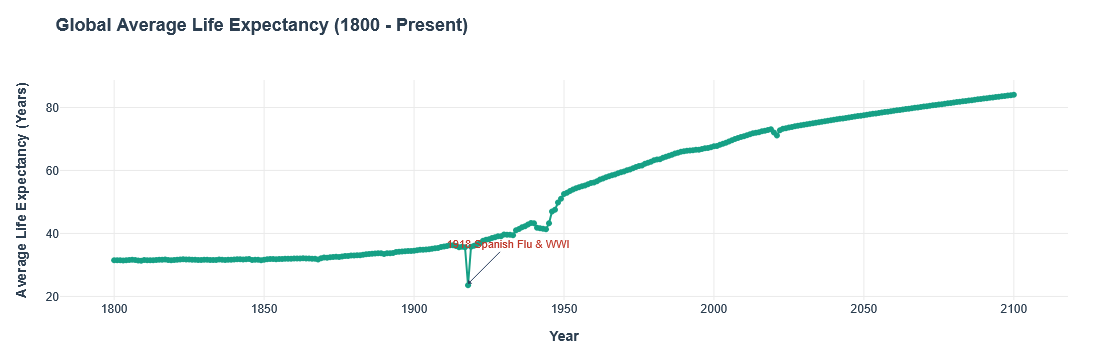

In [24]:
# Aggregate global average by year
trend = life.groupby("year")["life_expectancy"].mean().reset_index()

# Generate the line plot
fig = px.line(
    trend, 
    x="year", 
    y="life_expectancy",
    markers = True,
    color_discrete_sequence=["#16A085"]
)

# Style using helper
fig = style_figure(
    fig, 
    title="Global Average Life Expectancy (1800 - Present)",
    xlabel="Year",
    ylabel="Average Life Expectancy (Years)"
)

# Annotate the massive dip caused by the 1918 Spanish Flu
fig.add_annotation(
    x=1918, y=24,
    text="1918 Spanish Flu & WWI",
    showarrow=True,
    arrowhead=1,
    ax=40, ay=-40,
    font=dict(color="#C0392B", size=11)
)

fig.show()

**Insights:**
- A gradual increase from the early 1800s to the early 1900s, reflecting slow improvements in sanitation, nutrition, and public health.
- A much steeper rise after the mid-20th century, driven by advances such as antibiotics, vaccines, improved maternal and child healthcare, and expanded access to medical services.
- Stabilization in recent years, with gains becoming more gradual as many countries approach higher life expectancy levels.

**Question 2: Which countries have experienced the most radical change?**

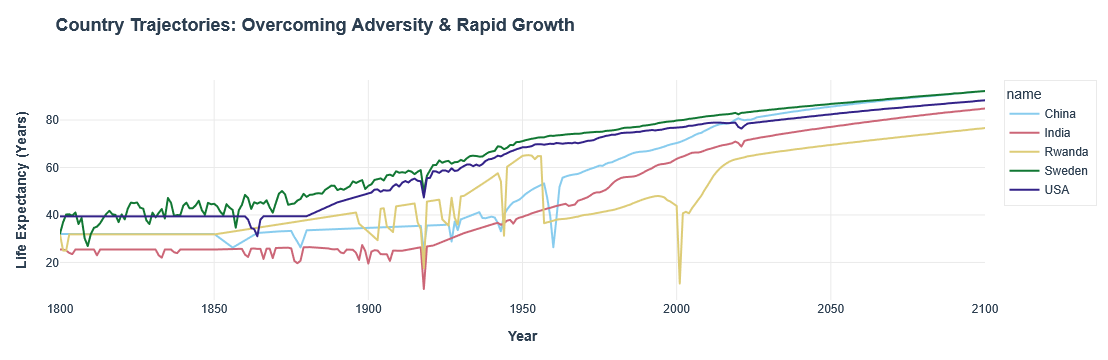

In [23]:
# Filter down to a few contrasting, illustrative countries
sample_countries = ["Sweden", "China", "USA", "Rwanda", "India"]
df_samples = life[life["name"].isin(sample_countries)]

fig_countries = px.line(
    df_samples, 
    x="year", 
    y="life_expectancy", 
    color="name",
    color_discrete_sequence=px.colors.qualitative.Safe
)

# Style using helper
fig_countries = style_figure(
    fig_countries, 
    title="Country Trajectories: Overcoming Adversity & Rapid Growth",
    xlabel="Year",
    ylabel="Life Expectancy (Years)"
)

fig_countries.show()

**Insight**
> __Rapid Convergence:__ Since the mid-1900s, developing nations like India and China have significantly closed the life expectancy gap with early developers like Sweden and the US.

> Global life expectancy has increased substantially over time, demonstrating long-term improvements in healthcare, disease prevention, living standards, and socioeconomic development. The most rapid gains occur during the second half of the 20th century, while future projections indicate continued but slower improvements as populations approach biological and public health limits.

__Question 3: How has the global distribution of lifespan shifted?__

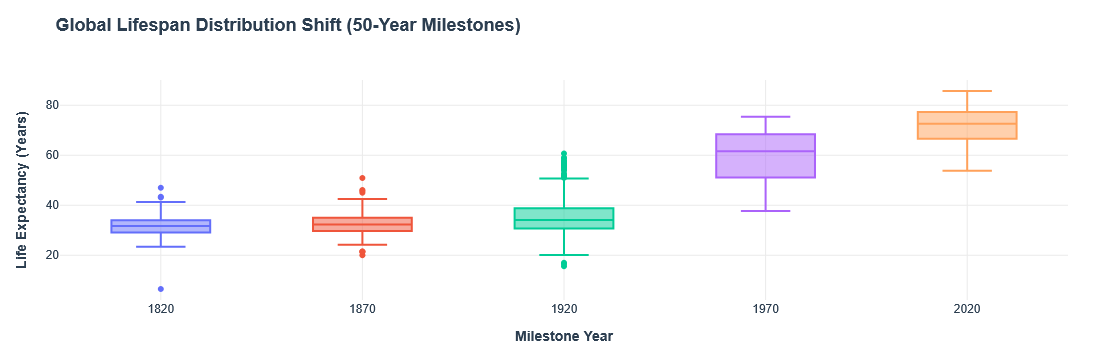

In [25]:
# Select target milestone years
milestones = [1820, 1870, 1920, 1970, 2020]
df_milestones = life[life["year"].isin(milestones)].copy()
df_milestones["year"] = df_milestones["year"].astype(str) # category conversion for plotting

fig_dist = px.box(
    df_milestones, 
    x="year", 
    y="life_expectancy",
    points="outliers",
    color="year", 
)

fig_dist = style_figure(
    fig_dist, 
    title="Global Lifespan Distribution Shift (50-Year Milestones)",
    xlabel="Milestone Year",
    ylabel="Life Expectancy (Years)",
    show_legend=False
)

fig_dist.show()

__Insight__
> **Inequality is Shrinking but Persists:** The boxplot milestone visualization reveals a tight global lifespan range in 1820 (where almost everyone died young), which widened aggressively during industrialization, and is now compressing again near the top of the scale (as modern medicine and sanitation scale globally).

**Question 4: How does Nigeria compare with neighboring countries?**

In [26]:
neighbors = [
    "Nigeria",
    "Benin",
    "Cameroon",
    "Chad",
    "Niger",
]

neighbor_df = life[
    life["name"].isin(neighbors)
]

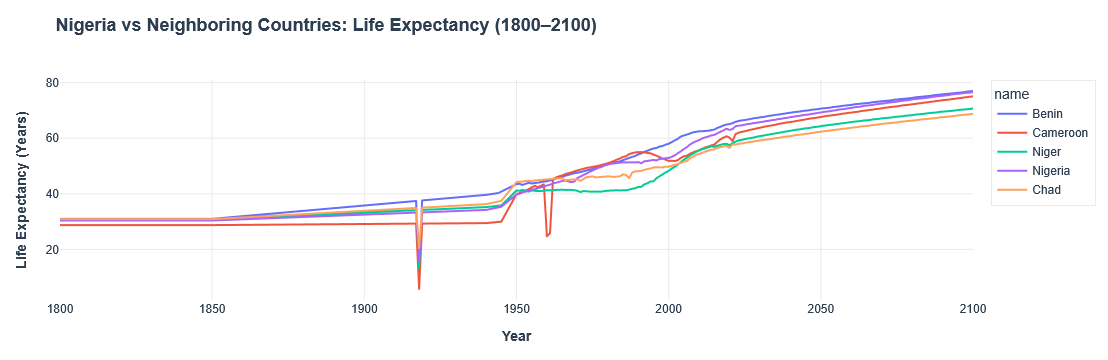

In [27]:
fig = px.line(
    neighbor_df,
    x="year",
    y="life_expectancy",
    color="name",
)

style_figure(
    fig,
    title="Nigeria vs Neighboring Countries: Life Expectancy (1800–2100)",
    xlabel="Year",
    ylabel="Life Expectancy (Years)"
)

fig.show()

In [28]:
avg_life = (
    neighbor_df
    .groupby("name", as_index=False)["life_expectancy"]
    .mean()
    .sort_values("life_expectancy")
)

avg_life

,name,life_expectancy
3,Niger,44.290000
1,Cameroon,44.682924
2,Chad,44.748472
4,Nigeria,46.594352
0,Benin,48.594518


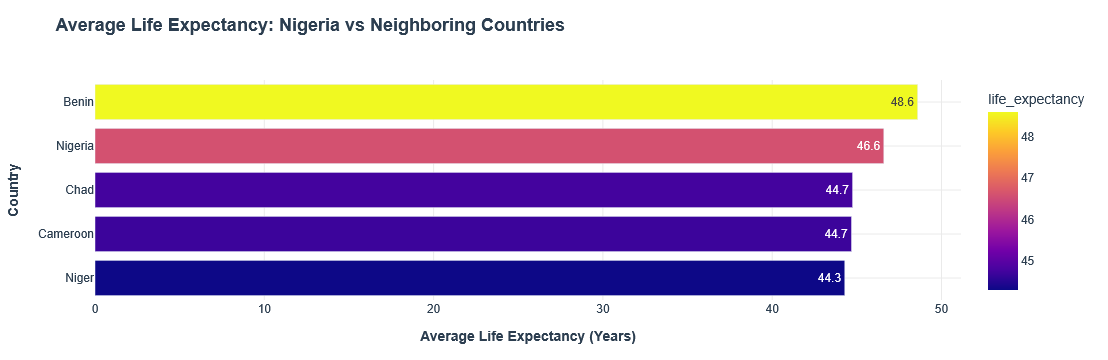

In [29]:
fig = px.bar(
    avg_life,
    x="life_expectancy",
    y="name",
    orientation="h",
    color="life_expectancy",
    text_auto=".1f"
)

style_figure(
    fig,
    title="Average Life Expectancy: Nigeria vs Neighboring Countries",
    xlabel="Average Life Expectancy (Years)",
    ylabel="Country"
)

fig.show()

In [30]:
comparison = (
    neighbor_df
    .pivot(
        index="name",
        columns="year",
        values="life_expectancy"
    )
)

comparison["Improvement"] = (
    comparison[2024] - comparison[1800]
)

comparison = (
    comparison["Improvement"]
    .sort_values(ascending=False)
    .reset_index()
)

comparison

,name,Improvement
0,Benin,35.42
1,Nigeria,34.22
2,Cameroon,33.54
3,Niger,28.59
4,Chad,27.21


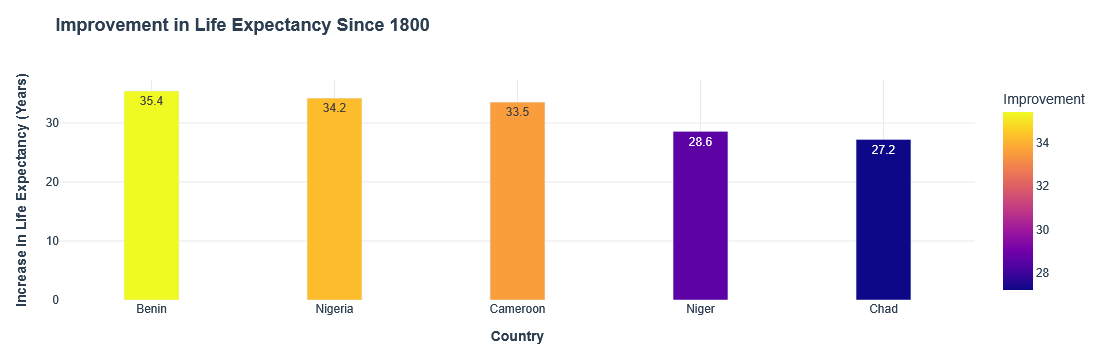

In [31]:
fig = px.bar(
    comparison,
    x="name",
    y="Improvement",
    color="Improvement",
    text_auto=".1f"
)
# Make the bars thinner
fig.update_traces(width=0.3)

style_figure(
    fig,
    title="Improvement in Life Expectancy Since 1800",
    xlabel="Country",
    ylabel="Increase in Life Expectancy (Years)"
)

fig.show()

__Insight:__
> Nigeria has experienced substantial gains in life expectancy over the past two centuries, reflecting improvements in healthcare, vaccination programs, sanitation, and living conditions. However, when compared with neighboring countries such as Benin, Cameroon, Chad, and Niger, its relative position depends on the time period examined. The trend analysis highlights whether Nigeria has kept pace with regional progress or whether disparities in health outcomes remain. 

**Question 5: What are the countries with greatest improvement?**

In [35]:
change = (
    life
    .pivot(index="name",
           columns="year",
           values="life_expectancy")
)

change["Increase"] = (
    change[2026]-change[1800]
)

change = (
    change["Increase"]
    .sort_values()
    .reset_index()
    .dropna()
)

In [36]:
change.tail(10)

,name,Increase
174,Kyrgyz Republic,51.68
175,Nicaragua,51.81
176,Israel,51.81
177,Iran,53.71
178,Italy,53.81
179,Spain,54.10
180,Malta,54.80
181,Kuwait,55.71
182,Singapore,56.71
183,South Korea,57.90


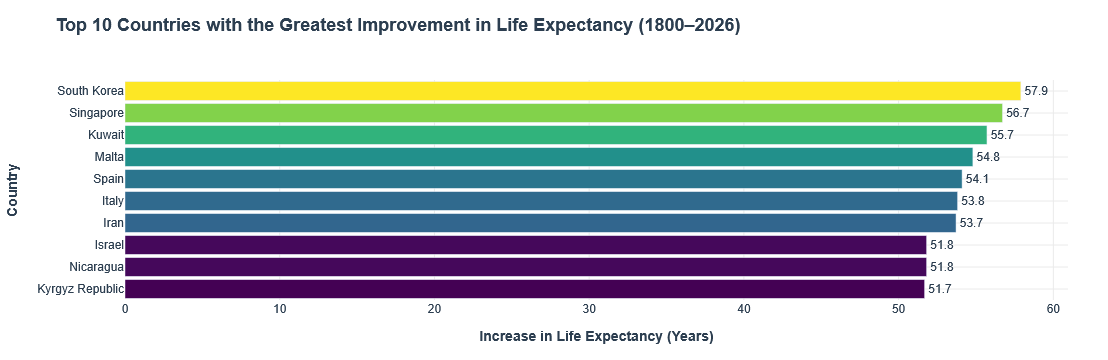

In [38]:
fig = px.bar(
    change.tail(10),
    x="Increase",
    y="name",
    orientation="h",
    color="Increase",
    color_continuous_scale="Viridis",
    text_auto=".1f"
)

fig.update_traces(
    textposition="outside",
    hovertemplate="<b>%{y}</b><br>Increase: %{x:.1f} years<extra></extra>"
)

fig.update_layout(
    bargap=0.15,
    coloraxis_showscale=False
)

style_figure(
    fig,
    title="Top 10 Countries with the Greatest Improvement in Life Expectancy (1800–2026)",
    xlabel="Increase in Life Expectancy (Years)",
    ylabel="Country"
)

fig.show()

**Question 6: What will be the life expectancy in Africa in the future?**

In [39]:
import pycountry
import pycountry_convert as pc

In [40]:
def get_continent(country_name):
    """
    Return the continent for a country name.
    Returns None if the country cannot be matched.
    """
    try:
        country = pycountry.countries.lookup(country_name)

        continent_code = pc.country_alpha2_to_continent_code(
            country.alpha_2
        )

        continent_name = {
            "AF": "Africa",
            "AS": "Asia",
            "EU": "Europe",
            "NA": "North America",
            "OC": "Oceania",
            "SA": "South America",
        }

        return continent_name.get(continent_code)

    except Exception:
        return None

In [41]:
life["Continent"] = life["name"].apply(get_continent)

life.head()

,geo,name,year,life_expectancy,Continent
0,afg,Afghanistan,1800,28.21,Asia
1,ago,Angola,1800,26.98,Africa
2,alb,Albania,1800,35.40,Europe
3,are,UAE,1800,30.70,None
4,arg,Argentina,1800,33.20,South America


In [48]:
africa = life[life["Continent"] == "Africa"]

africa_avg = (
    africa.groupby("year", as_index=False)["life_expectancy"]
    .mean()
)

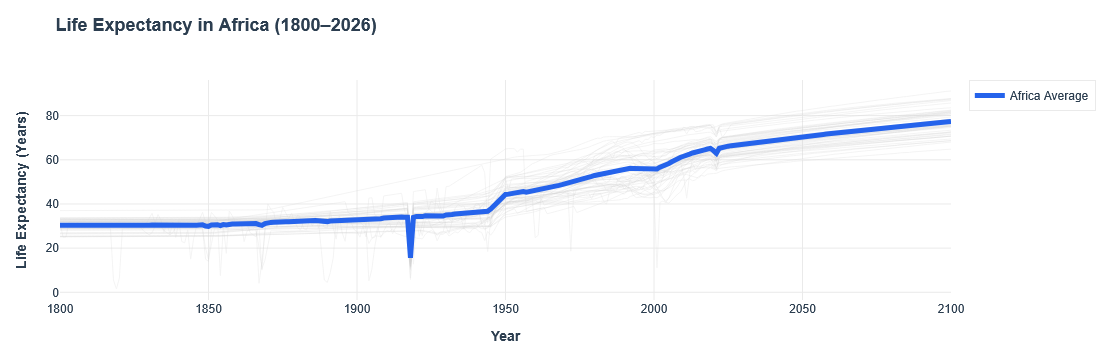

In [49]:
fig = go.Figure()

# Individual countries
for country, df in africa.groupby("name"):
    fig.add_trace(
        go.Scatter(
            x=df["year"],
            y=df["life_expectancy"],
            mode="lines",
            line=dict(width=1, color="lightgray"),
            opacity=0.25,
            showlegend=False,
            hoverinfo="skip"
        )
    )

# Continental average
fig.add_trace(
    go.Scatter(
        x=africa_avg["year"],
        y=africa_avg["life_expectancy"],
        mode="lines",
        name="Africa Average",
        line=dict(color="#2563EB", width=5)
    )
)

fig = style_figure(
    fig,
    "Life Expectancy in Africa (1800–2026)",
    "Year",
    "Life Expectancy (Years)"
)

fig.show()

__Insight:__
- Average life expectancy has increased dramatically over the last two centuries.
- By 2026, it is approximately __65–70__ years.
- The long-term trend suggests continued improvement, although future gains will depend on healthcare investments, disease control, political stability, and socioeconomic development.

#### __Key Insights__
1. **Life expectancy has increased significantly over time.**
- The global average life expectancy has risen steadily from the early 1800s to 2026.
- This reflects improvements in medicine, sanitation, nutrition, education, and public health.
2. **Africa has experienced remarkable progress.**
- Although Africa started with one of the lowest average life expectancies, the continent has shown consistent improvement over the last century.
- The sharpest increase occurred after the 1950s due to advances in healthcare and disease prevention.
3. **Regional disparities still exist.**
- Europe, North America, and Oceania generally maintain higher life expectancies than Africa and parts of Asia.
- This suggests that socioeconomic development and healthcare accessibility remain important determinants of longevity.
4. **Some countries improved faster than others.**
- Countries that invested heavily in healthcare infrastructure, education, and vaccination programs experienced larger gains in life expectancy.
- Political instability, conflict, and disease outbreaks slowed progress in some regions.
5. **Future projections remain optimistic.**
- Based on historical trends, Africa's average life expectancy is expected to continue increasing.
- However, the rate of improvement may gradually slow as countries approach higher life expectancy levels.

#### **Project Summary**

This project analyzed over two centuries of life expectancy data across countries and continents to understand how longevity has changed over time.

The analysis involved:

- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Trend analysis
- Continental comparisons
- Country-level comparisons
- Interactive visualizations using Plotly

The findings demonstrate that global life expectancy has improved dramatically due to continuous advances in healthcare, technology, education, and living standards. Despite this progress, inequalities remain across different regions, emphasizing the need for sustained investments in healthcare systems and socioeconomic development.

#### __Conclusion__

The analysis demonstrates one of humanity's greatest achievements: people are living significantly longer than they did two centuries ago.

Although challenges remain, particularly in developing regions, the overall trajectory is positive. Continued investments in healthcare, education, sanitation, and economic development will likely lead to further increases in life expectancy across the world.